# BESS Layout Optimization Engine

Standalone engineering notebook. All layout, sizing and routing logic lives in the shared `core` package (no dependency on the Streamlit app); rendering lives in `viz`. The app and this notebook call the **same** `build_config` + engine, so results match.

**System sizing inputs** — set `BESS_UNIT_MWH` (energy per BESS container) and `MVS_STATION_MW` (power per MVS) in the config cell below. Total MW / MWh and the 2H / 3H / 4H duration class are printed in the metrics table, the sizing cell, **and on every plot title.**


In [1]:
import sys, os
# Make the repo root importable (works whether the notebook sits at the root or in notebook/).
for cand in ('.', '..'):
    if os.path.isdir(os.path.join(cand, 'core')):
        sys.path.insert(0, os.path.abspath(cand)); break

from core import build_config, run_row_packing, run_colocated_optimization, size_system
from viz import plot_individual, print_comparison

# =========================================================
# SYSTEM SIZING INPUTS  <-- set your MWh / MW here
# =========================================================
BESS_UNIT_MWH  = 7.0    # energy per BESS container (MWh)
MVS_STATION_MW = 7.0    # power capacity per MVS station (MW)

# =========================================================
# SITE + EQUIPMENT CONFIGURATION  (single source via build_config)
# =========================================================
restricted_zone_1 = [(15.4, 0), (21.9, 0), (21.9, 96.9), (15.4, 96.9)]
restricted_zone_2 = [(21.9, 19.3), (21.9, 16), (53.3, 0), (61.3, 0)]
restricted_zone_3 = [(61.3, 0), (61.3, -8), (-8, -8), (-8, 0)]
restricted_zone_4 = [(-8, 0), (-22.7, 85.4), (-14.7, 78.9), (0, 0)]
restricted_zone_5 = [(-22.7, 85.4), (-14.7, 78.9), (15.4, 90.4), (15.4, 96.9)]

CONFIG = build_config(
    site_vertices=[
        (0, 0), (53.3, 0), (15.4, 19.3), (15.4, 90.4),(-14.7, 78.9)
        ],
    non_buildable=[restricted_zone_1, restricted_zone_2, restricted_zone_3, restricted_zone_4, restricted_zone_5],
    # restricted=[restricted_zone_1, restricted_zone_2, restricted_zone_3, restricted_zone_4, restricted_zone_5],
    # Per-side clearances (m). Width/height stay at the standard 6.06 x 2.44.
    bess_clearance={'front': 3.5, 'back': 0.15, 'left': 0.6, 'right': 2.0},
    mvs_clearance={'front': 3.0, 'back': 1.7,  'left': 2.0, 'right': 2.0},
    max_bess_per_mvs=4,
    max_cable_length=25,
    mvs_scoring_radius=25,
    min_mvs_spacing=0,
    grid_resolution=2.0,
    bess_unit_mwh=BESS_UNIT_MWH,
    mvs_station_mw=MVS_STATION_MW,
)

In [2]:
import time

# Row/shelf packer — true back-to-back rows that exploit the small back clearance.
t0 = time.perf_counter()
res = run_row_packing(CONFIG, verbose=True)
print(f"\nrow_pack -> {res['metrics']['bess_count']} BESS / {res['metrics']['mvs_count']} MVS "
      f"in {time.perf_counter()-t0:.1f} s")

scenarios = [res]
print_comparison(CONFIG, *scenarios)


----- ROW PACK (horizontal rows, MVS every 4) -----
MVS units placed   : 11
BESS units placed  : 42
Fully sat. MVS     : 9 / 11
Total cable        : 381.1 m
Capacity saturation: 95.5%

row_pack -> 42 BESS / 11 MVS in 4.1 s

────────────────────────────────────────
Metric              Row Pack            
────────────────────────────────────────
MVS Count           11                  
BESS Count          42                  
Total Power (MW)    77.0                
Total Energy (MWh)  294.0               
Duration            4H                  
Fully Sat. MVS      9 / 11              
Total Cable (m)     381.1               
Avg Cable (m)       9.1                 
Max Cable (m)       18.2                
Area Saturation     35.3%               
Capacity Sat.       95.5%               
────────────────────────────────────────


In [3]:
# System sizing per scenario: total MW / MWh and 2H / 3H / 4H duration class.
for res in scenarios:
    m = res['metrics']
    s = size_system(m['bess_count'], m['mvs_count'], BESS_UNIT_MWH, MVS_STATION_MW)
    print(f"{res['mode']:<18s} {s['total_mw']:6.1f} MW | {s['total_mwh']:7.1f} MWh | "
          f"{s['duration_h']:.2f} h -> {s['duration_label']}")

row_pack             77.0 MW |   294.0 MWh | 3.82 h -> 4H


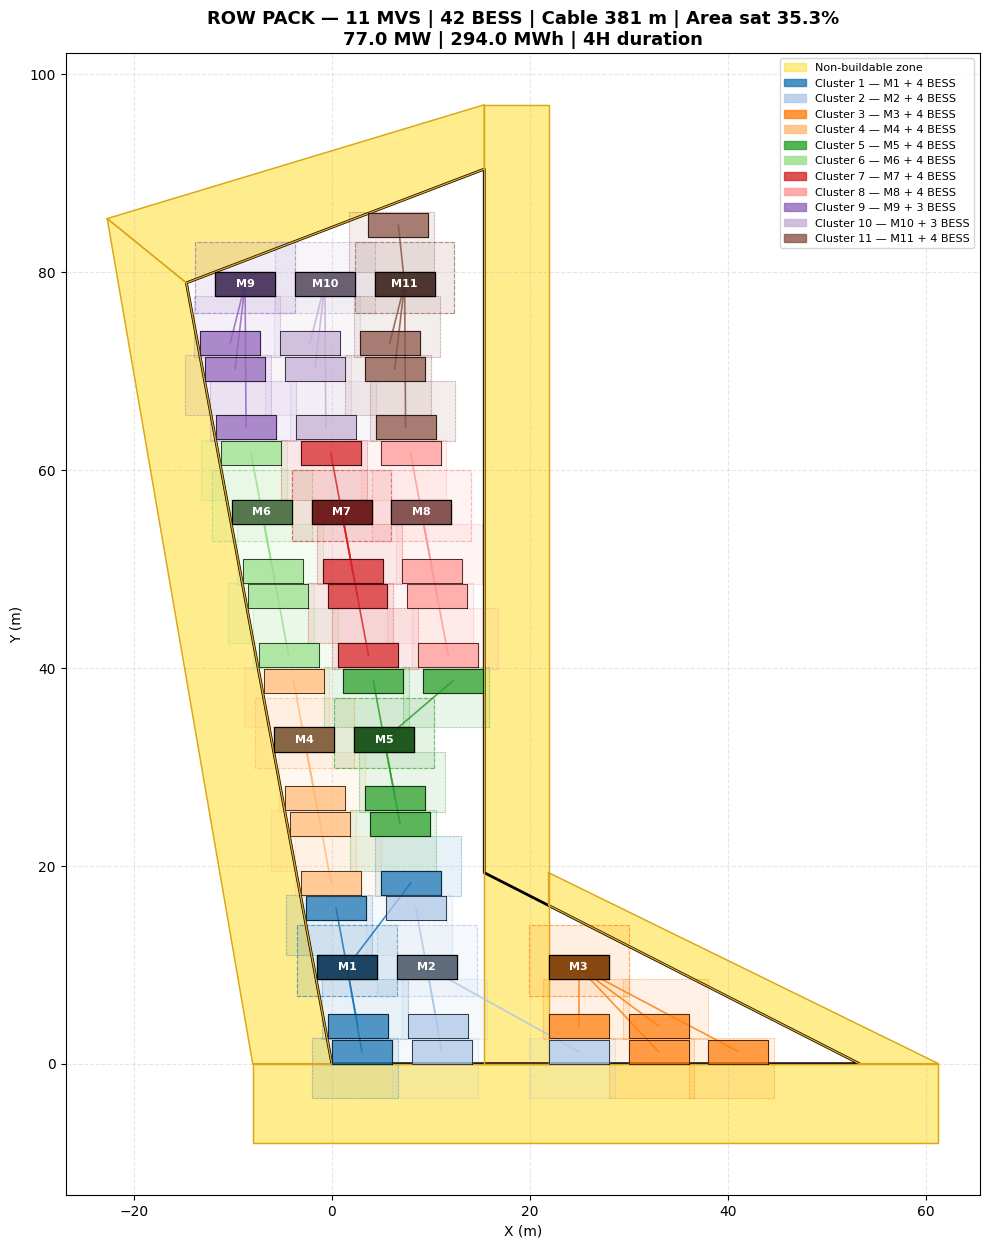

In [4]:
# Full-size layout (title shows MW | MWh | duration)
plot_individual(res, CONFIG)

In [5]:
# Optional: co-located / paired MVS scenario (shared-pad hubs)
CO_CONFIG = build_config(
    site_vertices=CONFIG['site_vertices'],
    non_buildable=[restricted_zone_1, restricted_zone_2, restricted_zone_3, restricted_zone_4, restricted_zone_5],
    bess_clearance={'front': 3.5, 'back': 0.15, 'left': 0.6, 'right': 2.0},
    mvs_clearance={'front': 3.0, 'back': 1.7,  'left': 2.0, 'right': 2.0},
    max_bess_per_mvs=4,
    bess_unit_mwh=BESS_UNIT_MWH,
    mvs_station_mw=MVS_STATION_MW,
    colocation={'enabled': True, 'group_size': 2, 'pad_gap': 0.5},
)
co_res = run_colocated_optimization(CO_CONFIG, verbose=True)
s = size_system(co_res['metrics']['bess_count'], co_res['metrics']['mvs_count'], BESS_UNIT_MWH, MVS_STATION_MW)
print(f"Co-located: {s['total_mw']:.1f} MW | {s['total_mwh']:.1f} MWh | {s['duration_label']}")


----- CO-LOCATED -----
Hubs placed        : 3
MVS units placed   : 6
BESS units placed  : 24
Avg BESS / hub     : 8.0
Hub balance index  : 0.00
Foundation saving  : 50.0%
Total cable        : 223.1 m
Co-located: 42.0 MW | 168.0 MWh | 4H
